# Stacking Ensemble

In [122]:
from matplotlib.pylab import logistic
import numpy as np
import pandas as pd

# bilstm_train= pd.read_csv('')
bilstm_valid= pd.read_csv('bilstm_validation_predictions.csv')
bilstm_test= pd.read_csv('bilstm_test_predictions.csv')

bilstm_valid_y = bilstm_valid['label']
bilstm_valid_x = bilstm_valid.drop('label', axis=1)
bilstm_test_y = bilstm_test['label']
bilstm_test_x = bilstm_test.drop('label', axis=1)

#cnn
cnn_train= pd.read_csv('cnn_train_preds.csv')
cnn_valid= pd.read_csv('cnn_valid_preds.csv')
cnn_test= pd.read_csv('cnn_test_preds.csv')

cnn_train_y = cnn_train['label']
cnn_train_x = cnn_train.drop('label', axis=1)
cnn_valid_y = cnn_valid['label']
cnn_valid_x = cnn_valid.drop('label', axis=1)
cnn_test_y = cnn_test['label']
cnn_test_x = cnn_test.drop('label', axis=1)

#logistic regression
logistic_train= pd.read_csv('logisticRegression_train_preds.csv')
logistic_valid= pd.read_csv('logisticRegression_valid_preds.csv')
logistic_test= pd.read_csv('logisticRegression_test_preds.csv')

logistic_train_y = logistic_train['label']
logistic_train_x = logistic_train.drop('label', axis=1)
logistic_valid_y = logistic_valid['label']
logistic_valid_x = logistic_valid.drop('label', axis=1)
logistic_test_y = logistic_test['label']
logistic_test_x = logistic_test.drop('label', axis=1)

#mlp
mlp_train= pd.read_csv('mlp_train_predictions.csv')
mlp_valid= pd.read_csv('mlp_valid_predictions.csv')
mlp_test= pd.read_csv('mlp_test_predictions.csv')

mlp_train_y = mlp_train['label']
mlp_train_x = mlp_train.drop('label', axis=1)
mlp_valid_y = mlp_valid['label']
mlp_valid_x = mlp_valid.drop('label', axis=1)
mlp_test_y = mlp_test['label']
mlp_test_x = mlp_test.drop('label', axis=1)

#random forest
random_forest_train= pd.read_csv('randomForest_train_preds.csv')
random_forest_valid= pd.read_csv('randomForest_valid_preds.csv')
random_forest_test= pd.read_csv('randomForest_test_preds.csv')

random_forest_train_y = random_forest_train['label']
random_forest_train_x = random_forest_train.drop('label', axis=1)
random_forest_valid_y = random_forest_valid['label']
random_forest_valid_x = random_forest_valid.drop('label', axis=1)
random_forest_test_y = random_forest_test['label']
random_forest_test_x = random_forest_test.drop('label', axis=1)

#naive bayes
naive_bayes_train= pd.read_csv('naiveBayes_train_preds.csv')
naive_bayes_valid= pd.read_csv('naiveBayes_valid_preds.csv')
naive_bayes_test= pd.read_csv('naiveBayes_test_preds.csv')

naive_bayes_train_y = naive_bayes_train['label']
naive_bayes_train_x = naive_bayes_train.drop('label', axis=1)
naive_bayes_valid_y = naive_bayes_valid['label']
naive_bayes_valid_x = naive_bayes_valid.drop('label', axis=1)
naive_bayes_test_y = naive_bayes_test['label']
naive_bayes_test_x = naive_bayes_test.drop('label', axis=1)

#svm 
svm_train= pd.read_csv('svm_train_preds.csv')
svm_valid= pd.read_csv('svm_valid_preds.csv')
svm_test= pd.read_csv('svm_test_preds.csv')

svm_train_y = svm_train['label']
svm_train_x = svm_train.drop('label', axis=1)
svm_valid_y = svm_valid['label']
svm_valid_x = svm_valid.drop('label', axis=1)
svm_test_y = svm_test['label']
svm_test_x = svm_test.drop('label', axis=1)

In [123]:
np.sum(bilstm_valid_y==random_forest_valid_y)/len(random_forest_valid_y)

1.0

In [124]:
X_meta_valid = pd.DataFrame({
    "bilstm_pred": bilstm_valid["prediction"],
    "bilstm_prob": bilstm_valid["probability"],

    "cnn_pred": cnn_valid["prediction"],
    "cnn_prob": cnn_valid["probability"],

    "logistic_pred": logistic_valid["prediction"],
    "logistic_prob": logistic_valid["probability"],

    "mlp_pred": mlp_valid["prediction"],
    "mlp_prob": mlp_valid["probability"],

    "rf_pred": random_forest_valid["prediction"],
    "rf_prob": random_forest_valid["probability"],

    "nb_pred": naive_bayes_valid["prediction"],
    "nb_prob": naive_bayes_valid["probability"],
    
    "svm_pred": svm_valid["prediction"],
    "svm_prob": svm_valid["probability"]
})

y_meta_valid = bilstm_valid["label"]

X_meta_test = pd.DataFrame({
    "bilstm_pred": bilstm_test["prediction"],
    "bilstm_prob": bilstm_test["probability"],

    "cnn_pred": cnn_test["prediction"],
    "cnn_prob": cnn_test["probability"],

    "logistic_pred": logistic_test["prediction"],
    "logistic_prob": logistic_test["probability"],

    "mlp_pred": mlp_test["prediction"],
    "mlp_prob": mlp_test["probability"],

    "rf_pred": random_forest_test["prediction"],
    "rf_prob": random_forest_test["probability"],

    "nb_pred": naive_bayes_test["prediction"],
    "nb_prob": naive_bayes_test["probability"],
    
    "svm_pred": svm_test["prediction"],
    "svm_prob": svm_test["probability"]
})

y_meta_test = bilstm_test["label"]



## general stacking

In [125]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_meta_valid_scaled = scaler.fit_transform(X_meta_valid)
X_meta_test_scaled = scaler.transform(X_meta_test)

meta = LogisticRegression(
    penalty="l2",
    C=1.0,
    solver="lbfgs",
    max_iter=2000
)

meta.fit(X_meta_valid_scaled, y_meta_valid)
meta_preds = meta.predict(X_meta_test_scaled)

print("Stacking test accuracy:",
      accuracy_score(y_meta_test, meta_preds))
print(classification_report(y_meta_test, meta_preds))


Stacking test accuracy: 0.8571428571428571
              precision    recall  f1-score   support

           0       0.88      0.86      0.87       526
           1       0.83      0.86      0.85       440

    accuracy                           0.86       966
   macro avg       0.86      0.86      0.86       966
weighted avg       0.86      0.86      0.86       966



In [126]:
# cross validated model
from sklearn.model_selection import StratifiedKFold, cross_val_score

meta = LogisticRegression(
    penalty="l1",
    C=.01,
    solver="liblinear",
    # max_iter=5000
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    meta,
    X_meta_valid_scaled,
    y_meta_valid,
    cv=cv,
    scoring="accuracy"
)

print("Meta CV accuracy:", cv_scores.mean(), "+/-", cv_scores.std())
meta.fit(X_meta_valid_scaled, y_meta_valid)
meta_preds = meta.predict(X_meta_test_scaled)

print("Stacking test accuracy:",
      accuracy_score(y_meta_test, meta_preds))
print(classification_report(y_meta_test, meta_preds))


Meta CV accuracy: 0.842113442113442 +/- 0.031066041917775015
Stacking test accuracy: 0.8581780538302277
              precision    recall  f1-score   support

           0       0.87      0.87      0.87       526
           1       0.84      0.85      0.84       440

    accuracy                           0.86       966
   macro avg       0.86      0.86      0.86       966
weighted avg       0.86      0.86      0.86       966



## find best hyperparameters

In [127]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler



X_meta_train, X_meta_val, y_meta_train, y_meta_val = train_test_split(
    X_meta_valid, y_meta_valid, test_size=0.20, random_state=42, stratify=y_meta_valid
)

scaler = StandardScaler()
X_meta_train = scaler.fit_transform(X_meta_train)
X_meta_val = scaler.transform(X_meta_val)
X_meta_test = scaler.transform(X_meta_test)





penalties = ["l1", "l2", "elasticnet"]
Cs = [0.01, 0.1, 1.0]
l1_ratios = [.3, .5, .8] 



results = []

best_acc = 0
best_params = None
best_stack = None
best_meta_model = None

for penalty in penalties:
    for C in Cs:
        if penalty == "elasticnet":
            for l1_ratio in l1_ratios:
                meta = LogisticRegression(
                    penalty=penalty,
                    C=C,
                    solver="saga",
                    l1_ratio=l1_ratio,
                    max_iter=5000,
                    random_state=42
                )
                
                meta.fit(X_meta_train, y_meta_train)
                val_acc = accuracy_score(y_meta_val, meta.predict(X_meta_val))
                print(f'penalty={penalty}, C={C}, l1_ratio={l1_ratio}, validation accuracy={val_acc}')
                results.append((penalty, C, l1_ratio, val_acc))
                if val_acc > best_acc:
                    best_acc = val_acc
                    best_params = (penalty, C, l1_ratio)
                    best_model = meta
        elif penalty == "l2":
            meta = LogisticRegression(
                penalty=penalty,
                C=C,
                solver="lbfgs",
                max_iter=5000,
                random_state=42
            )
            meta.fit(X_meta_train, y_meta_train)
            val_acc = accuracy_score(y_meta_val, meta.predict(X_meta_val))
            print(f'penalty={penalty}, C={C}, validation accuracy={val_acc}')
            results.append((penalty, C, val_acc))
            if val_acc > best_acc:
                best_acc = val_acc
                best_params = (penalty, C)
                best_model = meta
        elif penalty == "l1":
            meta = LogisticRegression(
                penalty=penalty,
                C=C,
                solver="liblinear",
                max_iter=5000,
                random_state=42
            )
            meta.fit(X_meta_train, y_meta_train)
            val_acc = accuracy_score(y_meta_val, meta.predict(X_meta_val))
            print(f'penalty={penalty}, C={C}, validation accuracy={val_acc}')
            results.append((penalty, C, val_acc))
            if val_acc > best_acc:
                best_acc = val_acc
                best_params = (penalty, C)
                best_model = meta
                


print("\nBest params:", best_params)
print("Best validation accuracy:", best_acc)

print("test accuracy")

best_preds= best_model.predict(X_meta_test)

print(classification_report(y_meta_test, best_preds))

penalty=l1, C=0.01, validation accuracy=0.8194444444444444
penalty=l1, C=0.1, validation accuracy=0.8472222222222222
penalty=l1, C=1.0, validation accuracy=0.8402777777777778
penalty=l2, C=0.01, validation accuracy=0.8333333333333334
penalty=l2, C=0.1, validation accuracy=0.8541666666666666
penalty=l2, C=1.0, validation accuracy=0.8472222222222222
penalty=elasticnet, C=0.01, l1_ratio=0.3, validation accuracy=0.8541666666666666
penalty=elasticnet, C=0.01, l1_ratio=0.5, validation accuracy=0.8541666666666666
penalty=elasticnet, C=0.01, l1_ratio=0.8, validation accuracy=0.8472222222222222
penalty=elasticnet, C=0.1, l1_ratio=0.3, validation accuracy=0.8541666666666666
penalty=elasticnet, C=0.1, l1_ratio=0.5, validation accuracy=0.8541666666666666
penalty=elasticnet, C=0.1, l1_ratio=0.8, validation accuracy=0.8472222222222222
penalty=elasticnet, C=1.0, l1_ratio=0.3, validation accuracy=0.8402777777777778
penalty=elasticnet, C=1.0, l1_ratio=0.5, validation accuracy=0.8402777777777778
penalty

## Best Model

In [128]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

model = LogisticRegression(
    penalty="l1",
    C=.01,
    solver="liblinear",
    # max_iter=5000
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    model,
    X_meta_valid_scaled,
    y_meta_valid,
    cv=cv,
    scoring="accuracy"
)

print("Meta CV accuracy:", cv_scores.mean(), "+/-", cv_scores.std())
model.fit(X_meta_valid_scaled, y_meta_valid)

Meta CV accuracy: 0.842113442113442 +/- 0.031066041917775015


,penalty,'l1'
,dual,False
,tol,0.0001
,C,0.01
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


## Boost model - aggregated dataset with most uncertain samples

In [129]:

probs = model.predict_proba(X_meta_valid_scaled)
uncertainty = 1 - np.max(probs, axis=1) 
k = 50 
most_uncertain_indices = np.argsort(uncertainty)[-k:]  # largest uncertainty
X_uncertain = X_meta_valid_scaled[most_uncertain_indices]
y_uncertain = y_meta_valid[most_uncertain_indices]
from sklearn.metrics.pairwise import cosine_similarity

m = 10 
similar_indices = []
for x in X_uncertain:
    sim = cosine_similarity(X_meta_valid_scaled, x.reshape(1, -1)).flatten()
    top_m = np.argsort(sim)[-m-1:-1]  
    similar_indices.extend(top_m)
    
augmented_indices = np.unique(np.concatenate([np.arange(len(X_meta_valid_scaled)), most_uncertain_indices, similar_indices]))
X_augmented = X_meta_valid_scaled[augmented_indices]
y_augmented = y_meta_valid[augmented_indices]
model.fit(X_augmented, y_augmented)
test_preds = model.predict(X_meta_test_scaled)

print(classification_report(y_meta_test, test_preds))

meta = LogisticRegression(
    penalty="l1",
    C=0.01,
    solver="liblinear",
    max_iter=5000
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(meta, X_augmented, y_augmented, cv=cv, scoring="accuracy")
print("Cross-validated accuracy on augmented data:", cv_scores.mean(), "+/-", cv_scores.std())

meta.fit(X_augmented, y_augmented)
meta_preds = meta.predict(X_meta_test_scaled)
print("Stacking test accuracy with CV model:")
print(classification_report(y_meta_test, meta_preds))

              precision    recall  f1-score   support

           0       0.87      0.87      0.87       526
           1       0.84      0.85      0.84       440

    accuracy                           0.86       966
   macro avg       0.86      0.86      0.86       966
weighted avg       0.86      0.86      0.86       966

Cross-validated accuracy on augmented data: 0.842113442113442 +/- 0.031066041917775015
Stacking test accuracy with CV model:
              precision    recall  f1-score   support

           0       0.87      0.87      0.87       526
           1       0.84      0.85      0.84       440

    accuracy                           0.86       966
   macro avg       0.86      0.86      0.86       966
weighted avg       0.86      0.86      0.86       966



## Feature analysis

In [130]:

from sklearn.model_selection import StratifiedKFold, cross_val_score
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
meta = LogisticRegression(
    penalty="l1",
    C=.01,
    solver="liblinear",
    # max_iter=5000
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    meta,
    X_meta_valid_scaled,
    y_meta_valid,
    cv=cv,
    scoring="accuracy"
)

meta.fit(X_meta_valid_scaled, y_meta_valid)
meta_preds = meta.predict(X_meta_test_scaled)




coefs = meta.coef_[0]  

# If you know the names of your base models or features:
# Example: suppose you have 5 base models and you used their predicted probs
feature_names = X_meta_valid.columns

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefs
})

# Sort by absolute value to see which models contribute most
coef_df["abs_coef"] = np.abs(coef_df["coefficient"])
coef_df = coef_df.sort_values(by="abs_coef", ascending=False)

print(coef_df)


          feature  coefficient  abs_coef
6        mlp_pred     0.478379  0.478379
12       svm_pred     0.385737  0.385737
0     bilstm_pred     0.159231  0.159231
4   logistic_pred     0.098098  0.098098
10        nb_pred     0.032949  0.032949
2        cnn_pred     0.000616  0.000616
1     bilstm_prob     0.000000  0.000000
3        cnn_prob     0.000000  0.000000
5   logistic_prob     0.000000  0.000000
7        mlp_prob     0.000000  0.000000
8         rf_pred     0.000000  0.000000
9         rf_prob     0.000000  0.000000
11        nb_prob     0.000000  0.000000
13       svm_prob     0.000000  0.000000


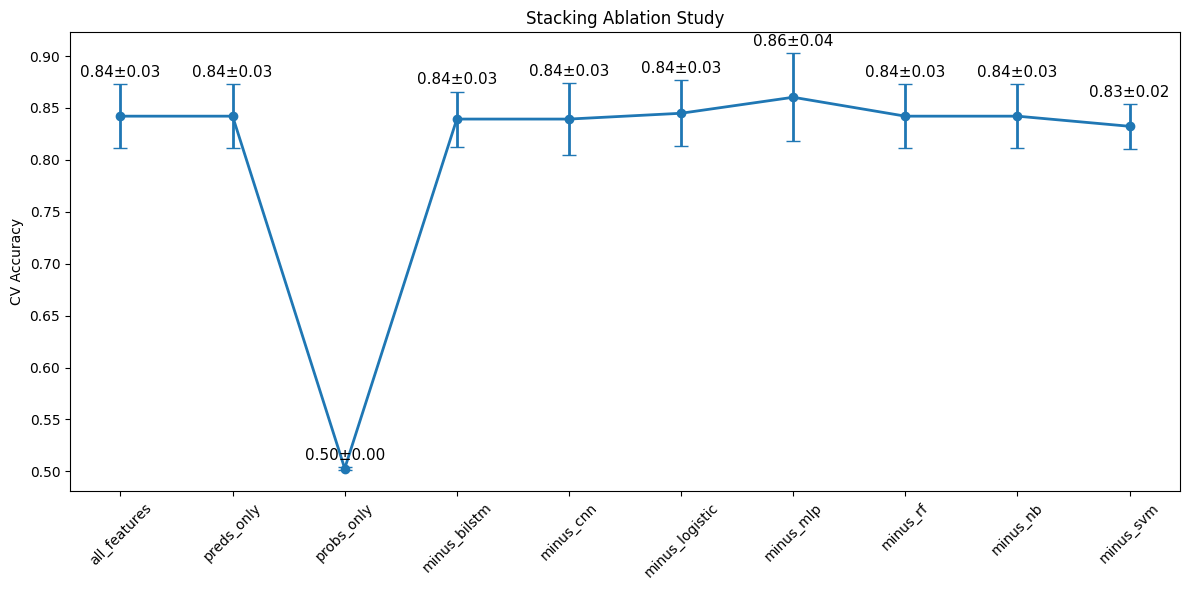

In [140]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
import matplotlib.pyplot as plt

# -------------------------------
pred_cols = [c for c in X_meta_valid.columns if "pred" in c]
prob_cols = [c for c in X_meta_valid.columns if "prob" in c]

model_prefixes = ["bilstm","cnn","logistic","mlp","rf","nb","svm"]


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

experiments = {}      

def score_model(X, name):
    model = LogisticRegression(penalty="l1", C=0.01, solver="liblinear")
    scores = cross_val_score(model, X, y_meta_valid, cv=cv, scoring="accuracy")
    experiments[name] = (scores.mean(), scores.std())



# 1. all features
score_model(X_meta_valid_scaled, "all_features")

# 2. only predictions
score_model(X_meta_valid_scaled[:, [X_meta_valid.columns.get_loc(c) for c in pred_cols]], 
            "preds_only")

# 3. only probs
score_model(X_meta_valid_scaled[:, [X_meta_valid.columns.get_loc(c) for c in prob_cols]], 
            "probs_only")

# 4. leave-one-model-out ablations
for m in model_prefixes:
    cols = [c for c in X_meta_valid.columns if not c.startswith(m+"_")]
    idxs = [X_meta_valid.columns.get_loc(c) for c in cols]
    score_model(X_meta_valid_scaled[:, idxs], f"minus_{m}")

# --# -----------------------------------
# plot results
# -----------------------------------
keys = list(experiments.keys())
means = [experiments[k][0] for k in keys]
stds  = [experiments[k][1] for k in keys]

plt.figure(figsize=(12,6))
plt.errorbar(
    keys,
    means,
    yerr=stds,
    fmt='-o',
    capsize=5,
    linewidth=2,
)
plt.xticks(rotation=45)
plt.ylabel("CV Accuracy")
plt.title("Stacking Ablation Study")

# add accuracy annotations above markers
for x, m, s in zip(keys, means, stds):
    plt.text(
        x,
        m + s + 0.007,            # slightly above error bar
        f"{m:.2f}±{s:.2f}",
        ha='center',
        fontsize=11
    )

plt.tight_layout()
plt.show()
